# 1. Import Libraries

## Objective

Import all libraries required for data manipulation and visualization in the executive dashboard.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# 2. Load Dataset

## Objective

Load the cleaned Cookie Cats dataset that will be used to recreate all dashboard metrics and visualizations.

This notebook is designed to run independently without relying on previous notebooks.

In [5]:
df = pd.read_csv("../data/cleaned/cookie_cats_cleaned.csv")

df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [11]:
# ============================
# Executive Dashboard Metrics
# ============================

# Total players
total_players = len(df)

# Players in each experiment group
gate30_players = (df["version"] == "gate_30").sum()
gate40_players = (df["version"] == "gate_40").sum()

# One-day retention (%)
ret1_gate30 = (
    df[df["version"] == "gate_30"]["retention_1"]
    .mean() * 100
)

ret1_gate40 = (
    df[df["version"] == "gate_40"]["retention_1"]
    .mean() * 100
)

# Seven-day retention (%)
ret7_gate30 = (
    df[df["version"] == "gate_30"]["retention_7"]
    .mean() * 100
)

ret7_gate40 = (
    df[df["version"] == "gate_40"]["retention_7"]
    .mean() * 100
)

In [6]:
# ---------------- Dashboard Theme ---------------- #

GREEN = "#2E8B57"      # Gate 30
GRAY = "#A9A9A9"       # Gate 40
BLUE = "#4C72B0"
ORANGE = "#DD8452"

TITLE_SIZE = 16
LABEL_SIZE = 12
TICK_SIZE = 11

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 11

# 3. Data Preparation

## 3.1 Objective

Prepare the dataset by creating player engagement segments and calculating the summary tables required for dashboard visualizations.

## 3.2 Create Player Engagement Segments

Classify players into Low, Medium, and High engagement groups based on the total number of game rounds played using quantile-based segmentation.

In [7]:
df["engagement_segment"] = pd.qcut(
    df["sum_gamerounds"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df["engagement_segment"].value_counts()

engagement_segment
Low       32224
High      29575
Medium    28390
Name: count, dtype: int64

## 3.3 Compute Overall Retention Metrics

Calculate the overall one-day and seven-day retention rates for both experiment groups.

In [8]:
ret1_gate30 = df[df.version=="gate_30"]["retention_1"].mean()*100
ret1_gate40 = df[df.version=="gate_40"]["retention_1"].mean()*100

ret7_gate30 = df[df.version=="gate_30"]["retention_7"].mean()*100
ret7_gate40 = df[df.version=="gate_40"]["retention_7"].mean()*100

## 3.4 Compute Segment-wise Retention

Calculate one-day and seven-day retention rates for each engagement segment.

In [9]:
segment_retention_1 = (
    df.groupby(["engagement_segment", "version"], observed=True)["retention_1"]
      .mean()
      .mul(100)
      .round(2)
      .unstack()
)

segment_retention_7 = (
    df.groupby(["engagement_segment", "version"], observed=True)["retention_7"]
      .mean()
      .mul(100)
      .round(2)
      .unstack()
)

# 4. Executive Dashboard

## 4.1 KPI Dashboard

Summarize the key experiment metrics that provide an executive overview of the A/B test.

These KPIs present the experiment size and the observed retention improvements between the two progression gate variants.

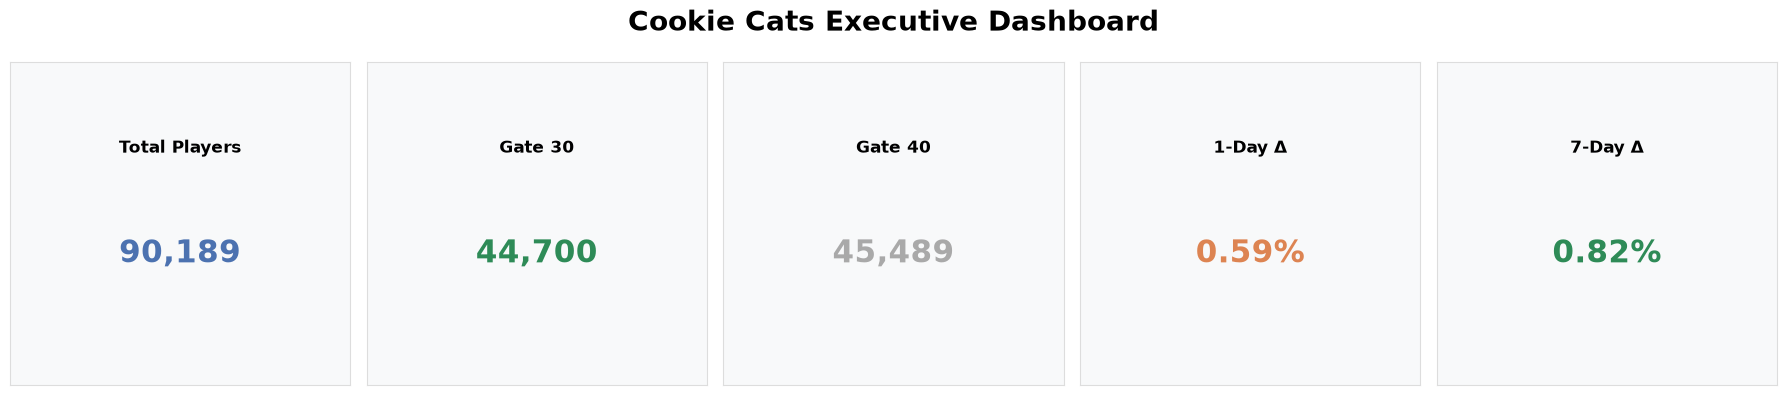

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(18,4))

cards = [
    ("Total Players", f"{len(df):,}"),
    ("Gate 30", f"{gate30_players:,}"),
    ("Gate 40", f"{gate40_players:,}"),
    ("1-Day Δ", f"{ret1_gate30-ret1_gate40:.2f}%"),
    ("7-Day Δ", f"{ret7_gate30-ret7_gate40:.2f}%")
]

colors = [BLUE, GREEN, GRAY, ORANGE, GREEN]

for ax, (title, value), color in zip(axes, cards, colors):

    ax.set_facecolor("#F8F9FA")

    ax.text(
        0.5,
        0.72,
        title,
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.38,
        value,
        ha="center",
        fontsize=22,
        fontweight="bold",
        color=color
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_color("#DDDDDD")

plt.suptitle(
    "Cookie Cats Executive Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../images/executive_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.2 Overall Retention Comparison

Compare one-day and seven-day retention between the two experiment groups.

This visualization provides a high-level summary of the experiment outcome before examining player segments.

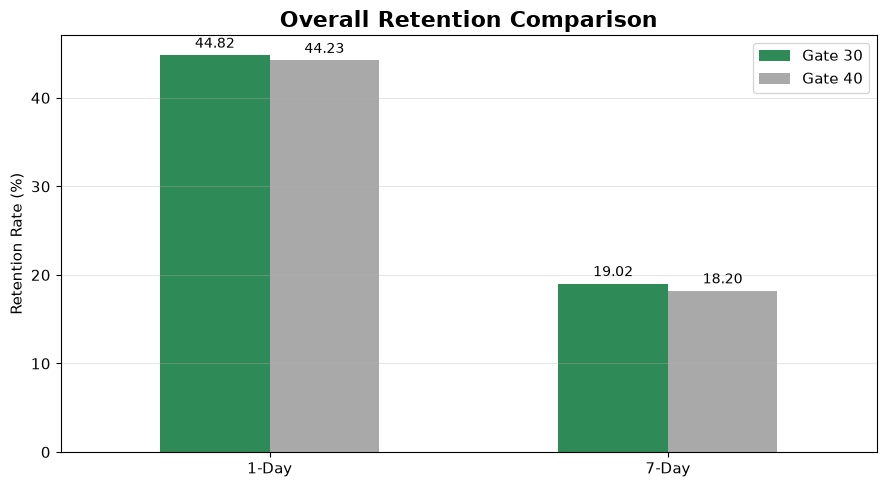

In [13]:
overall_retention = pd.DataFrame({
    "Gate 30":[ret1_gate30,ret7_gate30],
    "Gate 40":[ret1_gate40,ret7_gate40]
},index=["1-Day","7-Day"])

ax = overall_retention.plot(
    kind="bar",
    figsize=(9,5),
    color=[GREEN,GRAY],
    width=0.55
)

ax.set_title(
    "Overall Retention Comparison",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Retention Rate (%)")

ax.set_xlabel("")

ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=10,
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../images/overall_retention.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.3 Performance Improvement

This visualization summarizes the improvement in retention achieved by Gate 30 compared to Gate 40 for both one-day and seven-day retention.

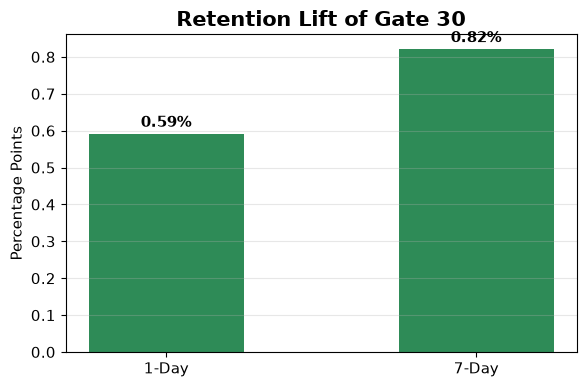

In [14]:
lift = pd.DataFrame({
    "Retention Metric":["1-Day","7-Day"],
    "Lift":[
        ret1_gate30-ret1_gate40,
        ret7_gate30-ret7_gate40
    ]
})

ax = plt.figure(figsize=(6,4))

bars = plt.bar(
    lift["Retention Metric"],
    lift["Lift"],
    color=GREEN,
    width=0.5
)

plt.title(
    "Retention Lift of Gate 30",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Percentage Points")

plt.grid(axis="y", alpha=0.3)

for bar in bars:

    y = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.02,
        f"{y:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "../images/retention_improvement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.4 Retention by Engagement Segment

Analyze how retention differs across Low, Medium, and High engagement players.

These visualizations help identify which player segments contribute most to the overall experiment results.

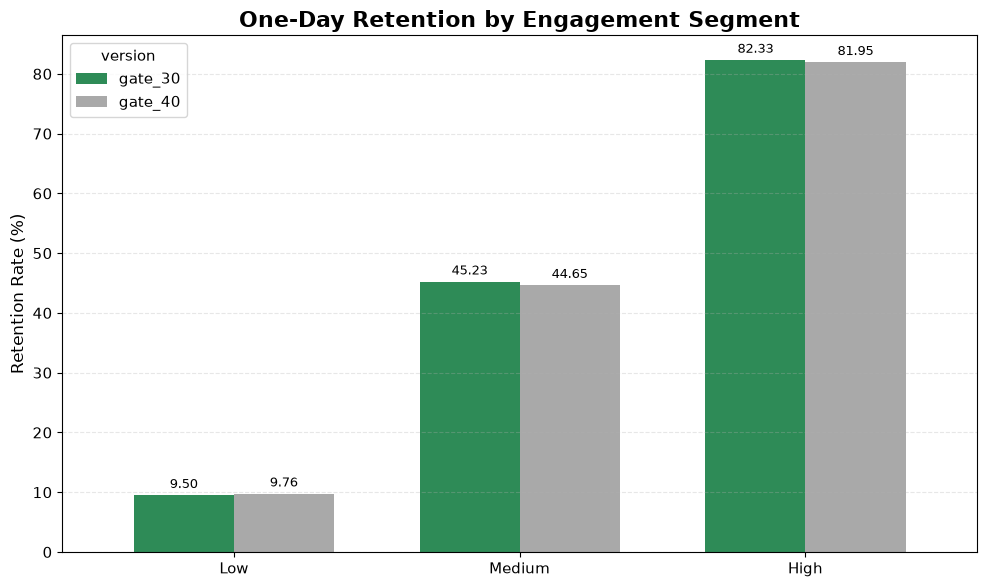

In [15]:
ax = segment_retention_1.plot(
    kind="bar",
    figsize=(10,6),
    color=[GREEN,GRAY],
    width=0.7
)

ax.set_title(
    "One-Day Retention by Engagement Segment",
    fontsize=TITLE_SIZE,
    fontweight="bold"
)

ax.set_xlabel("")

ax.set_ylabel(
    "Retention Rate (%)",
    fontsize=LABEL_SIZE
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()

plt.show()

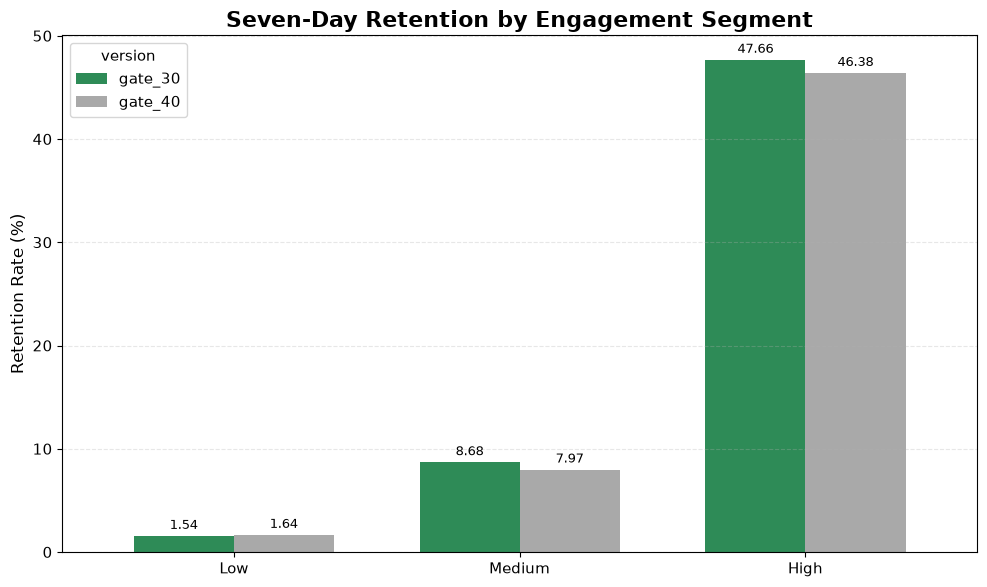

In [29]:
ax = segment_retention_7.plot(
    kind="bar",
    figsize=(10,6),
    color=[GREEN,GRAY],
    width=0.7
)

ax.set_title(
    "Seven-Day Retention by Engagement Segment",
    fontsize=TITLE_SIZE,
    fontweight="bold"
)

ax.set_xlabel("")

ax.set_ylabel(
    "Retention Rate (%)",
    fontsize=LABEL_SIZE
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()

plt.show()

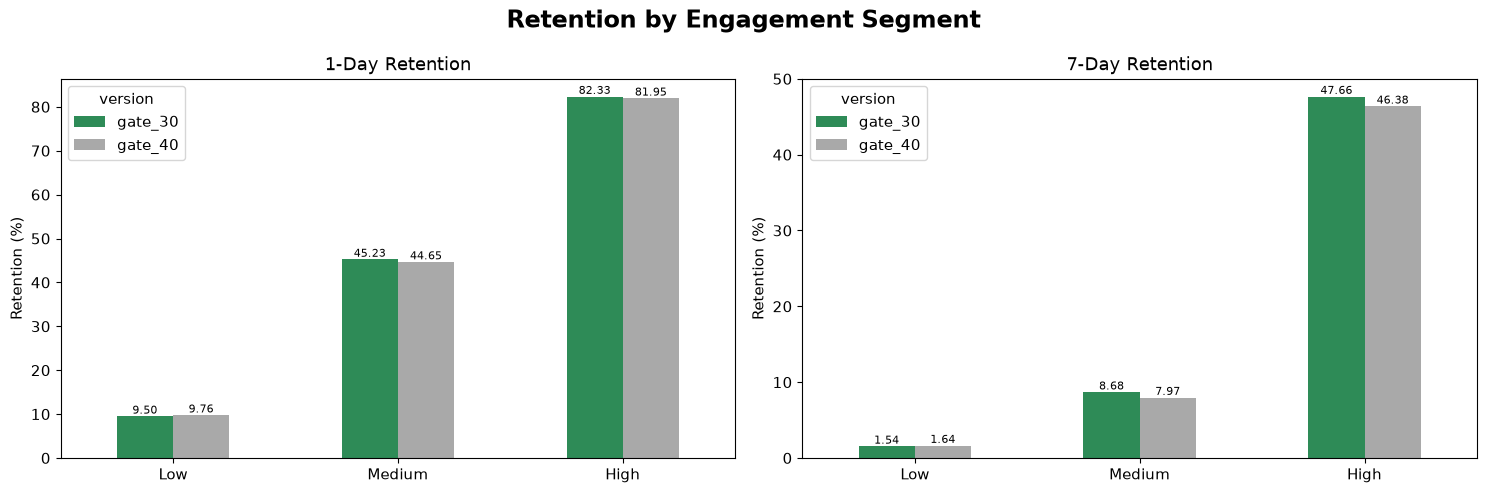

In [17]:
fig, axes = plt.subplots(1,2,figsize=(15,5))

segment_retention_1.plot(
    kind="bar",
    ax=axes[0],
    color=[GREEN,GRAY]
)

axes[0].set_title("1-Day Retention")

axes[0].set_xlabel("")
axes[0].set_ylabel("Retention (%)")
axes[0].tick_params(axis="x", rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", fontsize=8)

segment_retention_7.plot(
    kind="bar",
    ax=axes[1],
    color=[GREEN,GRAY]
)

axes[1].set_title("7-Day Retention")

axes[1].set_xlabel("")
axes[1].set_ylabel("Retention (%)")
axes[1].tick_params(axis="x", rotation=0)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", fontsize=8)

plt.suptitle(
    "Retention by Engagement Segment",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../images/segment_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.5 Player Engagement Distribution

Visualize the distribution of player activity to understand engagement patterns within the experiment population.

Since player activity is highly right-skewed, both the original and log-transformed distributions are presented.


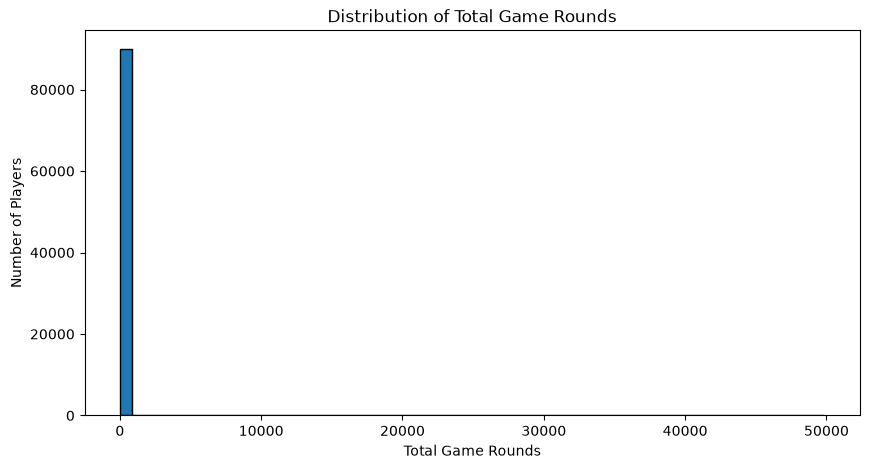

In [13]:
plt.figure(figsize=(10,5))

plt.hist(
    df["sum_gamerounds"],
    bins=60,
    edgecolor="black"
)

plt.title("Distribution of Total Game Rounds")

plt.xlabel("Total Game Rounds")

plt.ylabel("Number of Players")

plt.show()

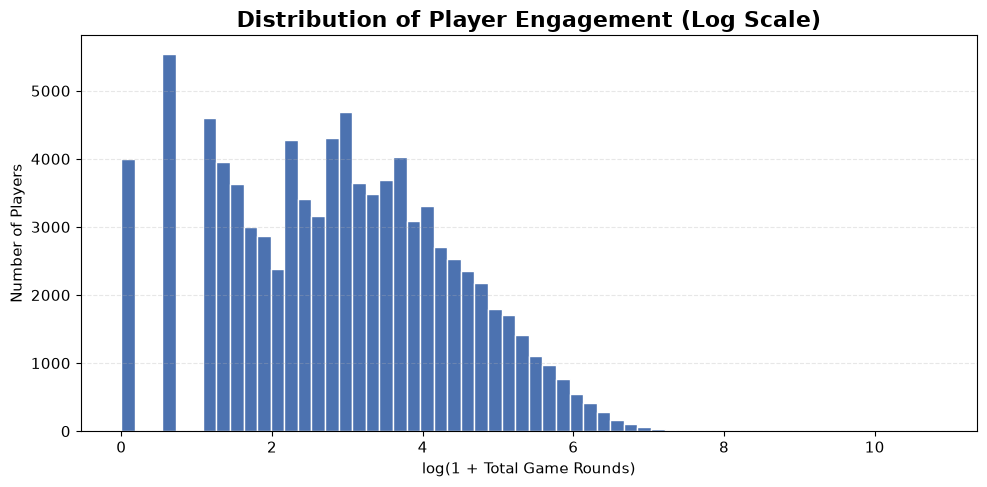

In [16]:
plt.figure(figsize=(10,5))

plt.hist(
    np.log1p(df["sum_gamerounds"]),
    bins=60,
    color=BLUE,
    edgecolor="white"
)

plt.title(
    "Distribution of Player Engagement (Log Scale)",
    fontsize=TITLE_SIZE,
    fontweight="bold"
)

plt.xlabel("log(1 + Total Game Rounds)")

plt.ylabel("Number of Players")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../images/engagement_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The original distribution is highly right-skewed, with most players completing relatively few game rounds while a small number of players exhibit exceptionally high engagement.

The log transformation provides a clearer view of the underlying distribution by reducing the influence of extreme values, making the overall engagement pattern easier to interpret.

## 4.5 Experiment Summary

Summarize the major analyses performed throughout the project and their key findings.

In [15]:
summary = pd.DataFrame({
    "Analysis": [
        "Sample Ratio Mismatch (SRM)",
        "One-Day Retention",
        "Seven-Day Retention",
        "Bootstrap Validation",
        "Power Analysis",
        "Segmentation Analysis"
    ],
    "Key Finding": [
        "Minor imbalance; acceptable for analysis",
        "No statistically significant difference",
        "Gate 30 significantly improved retention",
        "Bootstrap confirmed the statistical findings",
        "Study achieved 88.39% statistical power",
        "Medium and High engagement players benefited most"
    ]
})

summary


,Analysis,Key Finding
0,Sample Ratio Mismatch (SRM),Minor imbalance; acceptable for analysis
1,One-Day Retention,No statistically significant difference
2,Seven-Day Retention,Gate 30 significantly improved retention
3,Bootstrap Validation,Bootstrap confirmed the statistical findings
4,Power Analysis,Study achieved 88.39% statistical power
5,Segmentation Analysis,Medium and High engagement players benefited most


# 5. Executive Insights

## Key Insights

- The experiment included over **90,000 players**, providing a strong basis for statistical analysis.
- Player allocation between the two experiment groups was sufficiently balanced for reliable comparison.
- No statistically significant difference was observed in one-day retention.
- Seven-day retention was significantly higher for players assigned to **gate_30**.
- Bootstrap validation and power analysis confirmed the robustness of the findings.
- Segment-level analysis revealed that the improvement was primarily driven by Medium and High engagement players.

# 6. Executive Recommendation

## Final Recommendation

**Recommendation:** Maintain the progression gate at **Level 30**.

### Why?

The analyses consistently demonstrate that the original gate placement provides better long-term player retention without negatively affecting short-term engagement.

### Supporting Evidence

-  Seven-day retention is significantly higher for Gate 30.
-  Bootstrap analysis confirmed the robustness of the observed improvement.
-  Statistical power exceeded the recommended 80% threshold.
-  Medium and High engagement players benefited the most.
-  No meaningful disadvantage was observed in one-day retention.

### Business Impact

Maintaining the progression gate at Level 30 is expected to maximize long-term player retention while preserving a positive player experience. The evidence suggests that moving the gate to Level 40 would reduce long-term engagement among the game's most valuable players.

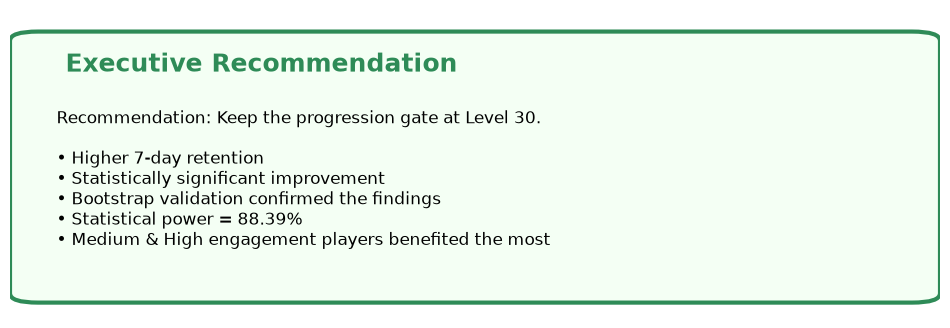

In [35]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12,4))

ax.set_xlim(0,1)
ax.set_ylim(0,1)

ax.axis("off")

card = FancyBboxPatch(
    (0.03,0.08),
    0.94,
    0.82,
    boxstyle="round,pad=0.03",
    edgecolor=GREEN,
    linewidth=3,
    facecolor="#F4FFF4"
)

ax.add_patch(card)

ax.text(
    0.05,
    0.80,
    " Executive Recommendation",
    fontsize=18,
    fontweight="bold",
    color=GREEN
)

recommendation = (
    "Recommendation: Keep the progression gate at Level 30.\n\n"
    "• Higher 7-day retention\n"
    "• Statistically significant improvement\n"
    "• Bootstrap validation confirmed the findings\n"
    "• Statistical power = 88.39%\n"
    "• Medium & High engagement players benefited the most"
)

ax.text(
    0.05,
    0.68,
    recommendation,
    fontsize=12,
    va="top"
)

plt.show()

# 7. Dashboard Summary

This executive dashboard consolidates the key findings from the Cookie Cats A/B experiment into a business-focused view.

Across hypothesis testing, bootstrap validation, power analysis, and engagement segmentation, the evidence consistently supports maintaining the progression gate at **Level 30**.

The experiment demonstrates that small design decisions can produce measurable improvements in long-term player retention, particularly among the most engaged players.